# VAE — Exploratory Data Analysis

## Datasets

### MNIST (teaching dataset)
- **Source**: `tensorflow.keras.datasets.mnist`
- **Shape**: 60,000 train / 10,000 test, 28x28 grayscale
- **Classes**: 10 digits (0-9), roughly balanced (5,421-6,742 per class)
- **Normalization**: [0, 1] float32

### CIFAR-10 (portfolio dataset)
- **Source**: `tensorflow.keras.datasets.cifar10`
- **Shape**: 50,000 train / 10,000 test, 32x32 RGB
- **Classes**: 10 objects (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), exactly 5,000 per class
- **Normalization**: [0, 1] float32

## Purpose

Understand what the VAE decoder needs to generate before designing architectures. Two datasets, two intents:
- **MNIST**: simple enough that 2D latent space is learnable and visualizable. Canonical VAE teaching benchmark — every portfolio reader has seen MNIST VAE results.
- **CIFAR-10**: enables direct FID comparison against GANs #14 (DCGAN FID 30.57). The honest "VAE is worse than GAN on natural images" data point.

Key questions: what does the pixel distribution look like (informs decoder output activation)? Is intra-class diversity high enough to challenge the latent space? Any class imbalance that would skew reconstruction toward majority classes?

## EDA Steps

1. Sample image grids — 5x10 diversity check for both datasets
2. Pixel intensity histograms — both datasets should peak at black (MNIST) or mid-gray (CIFAR-10 means)
3. Class balance — confirm preprocessing_info matches reality
4. Per-class sample diversity — pick one class from each dataset, show 10 samples

In [1]:
# Step 1: Setup

"""
Load MNIST + CIFAR-10 from VAE preprocessing cache.
Both are already float32 in [0, 1] - no normalization here,
just inspection.
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)

# EDA output dir for saved plots
EDA_DIR = '../data/raw/eda_vae'
os.makedirs(EDA_DIR, exist_ok=True)

# Load from preprocessing cache (notebook CWD is data-preperation/)
VAE_DIR = '../data/processed/vae'
MNIST_DIR = os.path.join(VAE_DIR, 'mnist')
CIFAR10_DIR = os.path.join(VAE_DIR, 'cifar10')

mnist_X_train = np.load(os.path.join(MNIST_DIR, 'X_train.npy'))
mnist_X_test  = np.load(os.path.join(MNIST_DIR, 'X_test.npy'))
mnist_y_train = np.load(os.path.join(MNIST_DIR, 'y_train.npy'))
mnist_y_test  = np.load(os.path.join(MNIST_DIR, 'y_test.npy'))

cifar_X_train = np.load(os.path.join(CIFAR10_DIR, 'X_train.npy'))
cifar_X_test  = np.load(os.path.join(CIFAR10_DIR, 'X_test.npy'))
cifar_y_train = np.load(os.path.join(CIFAR10_DIR, 'y_train.npy'))
cifar_y_test  = np.load(os.path.join(CIFAR10_DIR, 'y_test.npy'))

with open(os.path.join(MNIST_DIR, 'preprocessing_info.json')) as f:
    mnist_info = json.load(f)
with open(os.path.join(CIFAR10_DIR, 'preprocessing_info.json')) as f:
    cifar_info = json.load(f)

MNIST_CLASS_NAMES = mnist_info['class_names']
CIFAR_CLASS_NAMES = cifar_info['class_names']

print("=" * 60)
print("VAE - Exploratory Data Analysis")
print("=" * 60)

print(f"\nMNIST")
print(f"    Train: {mnist_X_train.shape}  ({mnist_X_train.dtype})")
print(f"    Test:  {mnist_X_test.shape}   ({mnist_X_test.dtype})")
print(f"    Range: [{mnist_X_train.min():.2f}, {mnist_X_train.max():.2f}]")
print(f"    Classes: {len(MNIST_CLASS_NAMES)} ({MNIST_CLASS_NAMES})")
print(f"    Per-class train counts: {np.bincount(mnist_y_train).tolist()}")

print(f"\nCIFAR-10")
print(f"    Train: {cifar_X_train.shape}  ({cifar_X_train.dtype})")
print(f"    Test:  {cifar_X_test.shape}   ({cifar_X_test.dtype})")
print(f"    Range: [{cifar_X_train.min():.2f}, {cifar_X_train.max():.2f}]")
print(f"    Classes: {len(CIFAR_CLASS_NAMES)}")
for i, name in enumerate(CIFAR_CLASS_NAMES):
    print(f"        {i}: {name}")

VAE - Exploratory Data Analysis

MNIST
    Train: (60000, 28, 28)  (float32)
    Test:  (10000, 28, 28)   (float32)
    Range: [0.00, 1.00]
    Classes: 10 (['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
    Per-class train counts: [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]

CIFAR-10
    Train: (50000, 32, 32, 3)  (float32)
    Test:  (10000, 32, 32, 3)   (float32)
    Range: [0.00, 1.00]
    Classes: 10
        0: airplane
        1: automobile
        2: bird
        3: cat
        4: deer
        5: dog
        6: frog
        7: horse
        8: ship
        9: truck


[1/4] Sample Image Grids


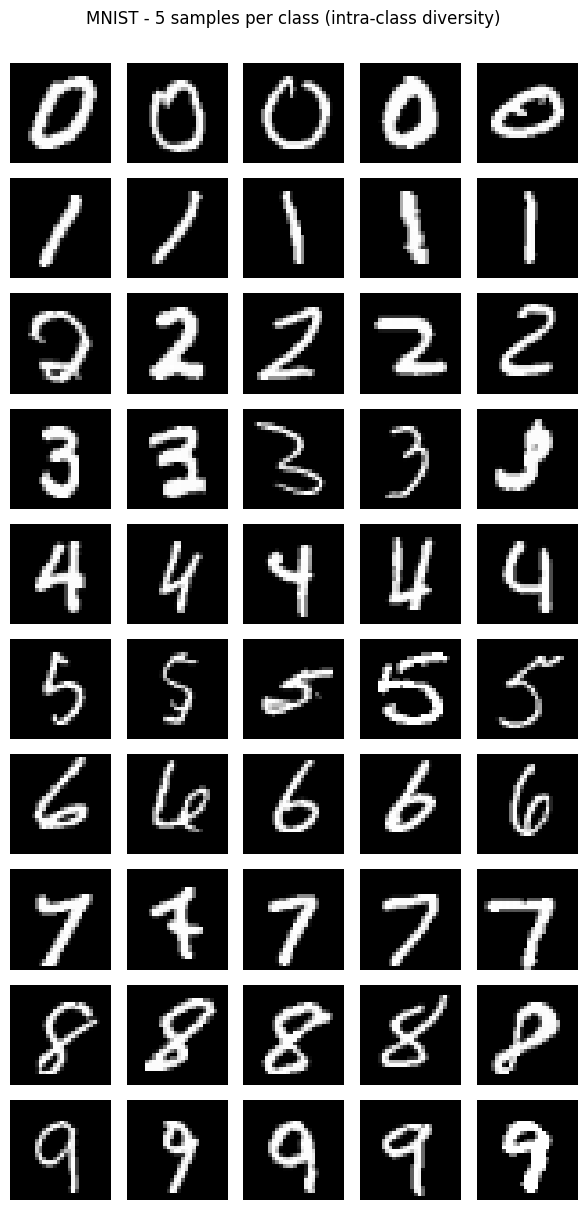

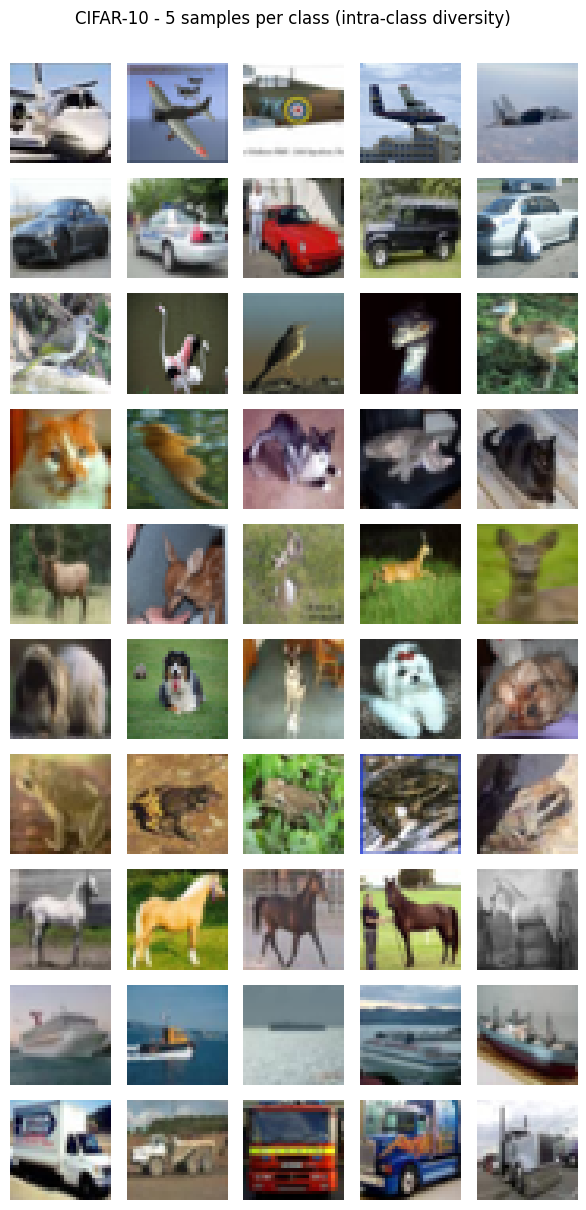


    Saved: ../data/raw/eda_vae/eda_mnist_samples.png
    Saved: ../data/raw/eda_vae/eda_cifar10_samples.png


In [2]:
# Step 2: Sample Image Grids

"""
Visual diversity check for both datasets. For each of 10 classes,
show 5 random examples. Same grid layout for both datasets so the
portfolio reader can compare intra-class variation side-by-side.

MNIST: simple digit shapes, mostly intra-class similar (a '0' looks
like a '0'). VAE decoder should converge quickly on MNIST.

CIFAR-10: 32x32 pixels for 'dog' must represent dogs of all breeds,
colors, poses. High intra-class diversity = harder VAE target =
blurrier samples = FID gap vs GANs #14.
"""

print("=" * 60)
print("[1/4] Sample Image Grids")
print("=" * 60)


def _class_sample_grid(X, y, class_names, n_per_class, cmap=None,
                       fig_title='', save_path=None):
    # Build a len(class_names) x n_per_class grid: rows=classes, cols=samples
    n_classes = len(class_names)
    fig, axes = plt.subplots(
        n_classes, n_per_class,
        figsize=(n_per_class * 1.2, n_classes * 1.2),
    )
    rng = np.random.default_rng(RANDOM_STATE)
    for cls_idx in range(n_classes):
        cls_mask = (y == cls_idx)
        cls_indices = np.where(cls_mask)[0]
        picks = rng.choice(cls_indices, size=n_per_class, replace=False)
        for col, pick in enumerate(picks):
            ax = axes[cls_idx, col]
            ax.imshow(X[pick], cmap=cmap)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(class_names[cls_idx], rotation=0, ha='right',
                              va='center', fontsize=9)
    fig.suptitle(fig_title, fontsize=12, y=1.005)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# MNIST grid (grayscale)
_class_sample_grid(
    mnist_X_train, mnist_y_train, MNIST_CLASS_NAMES, n_per_class=5,
    cmap='gray',
    fig_title='MNIST - 5 samples per class (intra-class diversity)',
    save_path=os.path.join(EDA_DIR, 'eda_mnist_samples.png'),
)

# CIFAR-10 grid (RGB)
_class_sample_grid(
    cifar_X_train, cifar_y_train, CIFAR_CLASS_NAMES, n_per_class=5,
    cmap=None,
    fig_title='CIFAR-10 - 5 samples per class (intra-class diversity)',
    save_path=os.path.join(EDA_DIR, 'eda_cifar10_samples.png'),
)

print(f"\n    Saved: {EDA_DIR}/eda_mnist_samples.png")
print(f"    Saved: {EDA_DIR}/eda_cifar10_samples.png")

[2/4] Pixel Intensity Distributions + Class Balance

MNIST pixel stats:    mean=0.1307, std=0.3081
CIFAR-10 pixel stats: mean=0.4734, std=0.2516

MNIST:    81.8% near black (<0.05), 7.9% near white (>0.95)
CIFAR-10: 2.5% near black (<0.05), 3.8% near white (>0.95)


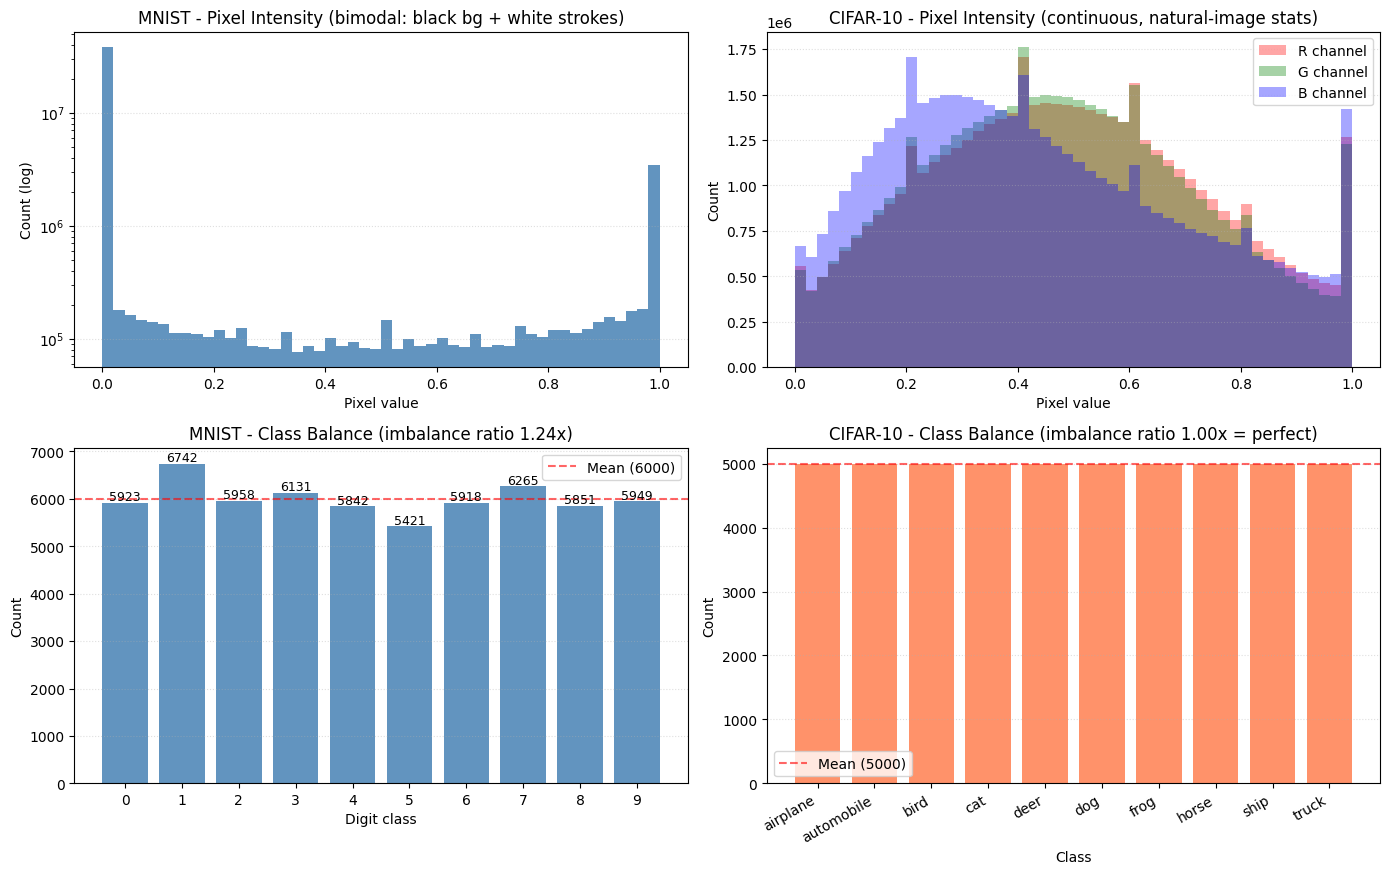


    Saved: ../data/raw/eda_vae/eda_pixel_and_class_stats.png


In [ ]:
# Step 3: Pixel Intensity Distributions + Class Balance

"""
Two concerns for VAE decoder design:

1. Pixel intensity distribution informs decoder output activation.
   Both datasets are in [0, 1] - sigmoid output is appropriate.
   But MNIST is bimodal (mostly 0 or 1, few mid-tones) while
   CIFAR-10 is continuous - this affects whether BCE or Gaussian
   likelihood is the better loss.

2. Class balance - confirmed preprocessing info matches reality.
   MNIST has 1.24x imbalance (1=6742 vs 5=5421); CIFAR-10 is
   exactly balanced.
"""

print("=" * 60)
print("[2/4] Pixel Intensity Distributions + Class Balance")
print("=" * 60)

# Pixel stats
mnist_mean, mnist_std = mnist_X_train.mean(), mnist_X_train.std()
cifar_mean, cifar_std = cifar_X_train.mean(), cifar_X_train.std()
print(f"\nMNIST pixel stats:    mean={mnist_mean:.4f}, std={mnist_std:.4f}")
print(f"CIFAR-10 pixel stats: mean={cifar_mean:.4f}, std={cifar_std:.4f}")

# Fraction of pixels at extremes (near 0 or near 1)
mnist_dark  = (mnist_X_train < 0.05).mean()
mnist_bright = (mnist_X_train > 0.95).mean()
cifar_dark  = (cifar_X_train < 0.05).mean()
cifar_bright = (cifar_X_train > 0.95).mean()
print(f"\nMNIST:    {mnist_dark * 100:.1f}% near black (<0.05), {mnist_bright * 100:.1f}% near white (>0.95)")
print(f"CIFAR-10: {cifar_dark * 100:.1f}% near black (<0.05), {cifar_bright * 100:.1f}% near white (>0.95)")

"""
Plot: 2 rows x 2 cols
top-left: MNIST pixel histogram
top-right: CIFAR-10 pixel histogram (per-channel RGB)
bot-left: MNIST class balance
bot-right: CIFAR-10 class balance
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: MNIST pixel histogram (log y)
axes[0, 0].hist(mnist_X_train.ravel(), bins=50, color='steelblue', alpha=0.85)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Pixel value'); axes[0, 0].set_ylabel('Count (log)')
axes[0, 0].set_title(f'MNIST - Pixel Intensity (bimodal: black bg + white strokes)')
axes[0, 0].grid(axis='y', ls=':', alpha=0.4)

# Top-right: CIFAR-10 per-channel histogram (more continuous)
for ch_idx, (ch_name, color) in enumerate(zip(['R', 'G', 'B'], ['red', 'green', 'blue'])):
    axes[0, 1].hist(
        cifar_X_train[..., ch_idx].ravel(), bins=50,
        color=color, alpha=0.35, label=f'{ch_name} channel',
    )
axes[0, 1].set_xlabel('Pixel value'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('CIFAR-10 - Pixel Intensity (continuous, natural-image stats)')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', ls=':', alpha=0.4)

# Bot-left: MNIST class balance
mnist_counts = np.bincount(mnist_y_train)
axes[1, 0].bar(range(10), mnist_counts, color='steelblue', alpha=0.85)
axes[1, 0].set_xticks(range(10))
axes[1, 0].set_xticklabels(MNIST_CLASS_NAMES)
axes[1, 0].set_xlabel('Digit class'); axes[1, 0].set_ylabel('Count')
axes[1, 0].axhline(mnist_counts.mean(), color='red', ls='--', alpha=0.6,
                   label=f'Mean ({mnist_counts.mean():.0f})')
axes[1, 0].set_title(
    f'MNIST - Class Balance '
    f'(imbalance ratio {mnist_counts.max() / mnist_counts.min():.2f}x)',
)
for i, c in enumerate(mnist_counts):
    axes[1, 0].text(i, c + 50, str(c), ha='center', fontsize=9)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', ls=':', alpha=0.4)

# Bot-right: CIFAR-10 class balance
cifar_counts = np.bincount(cifar_y_train)
axes[1, 1].bar(range(10), cifar_counts, color='coral', alpha=0.85)
axes[1, 1].set_xticks(range(10))
axes[1, 1].set_xticklabels(CIFAR_CLASS_NAMES, rotation=30, ha='right')
axes[1, 1].set_xlabel('Class'); axes[1, 1].set_ylabel('Count')
axes[1, 1].axhline(cifar_counts.mean(), color='red', ls='--', alpha=0.6,
                   label=f'Mean ({cifar_counts.mean():.0f})')
axes[1, 1].set_title(
    f'CIFAR-10 - Class Balance '
    f'(imbalance ratio {cifar_counts.max() / cifar_counts.min():.2f}x = perfect)',
)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'eda_pixel_and_class_stats.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n    Saved: {EDA_DIR}/eda_pixel_and_class_stats.png")

[3/4] Class Mean Images + Per-Pixel Variance


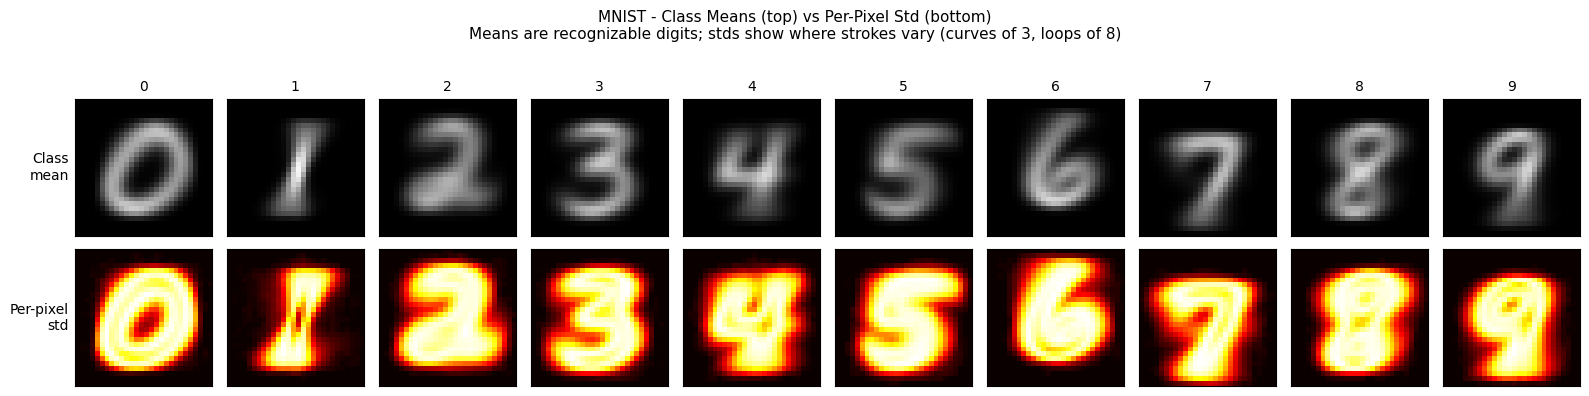

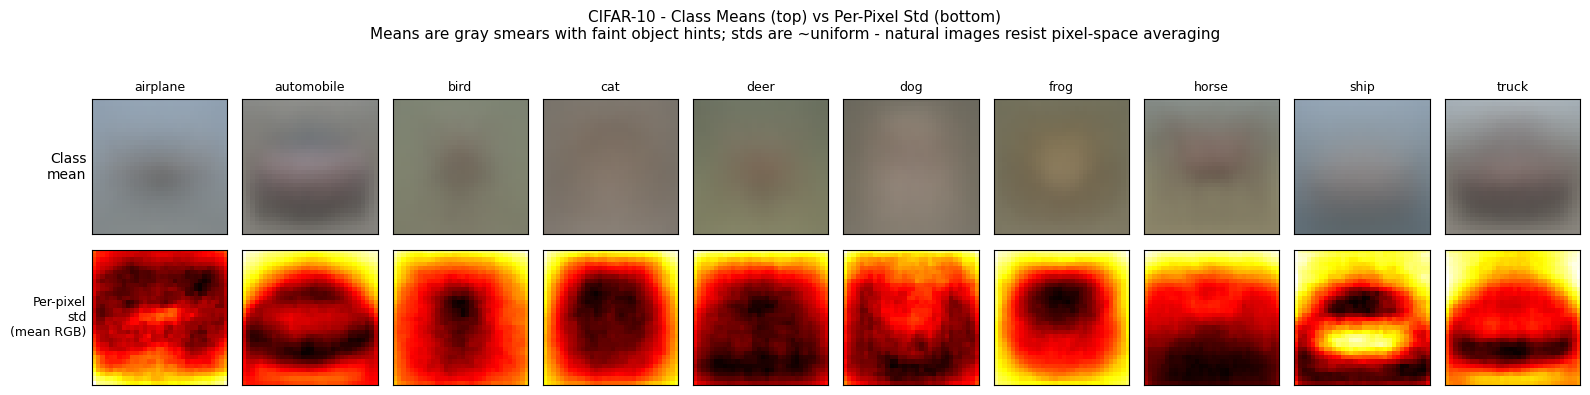


MNIST class means:
    Pixel range: [0.000, 0.966]
    Class 'blurriness' (mean std across pixels per class):
        0: mean=0.173, avg std=0.176
        1: mean=0.076, avg std=0.095
        2: mean=0.149, avg std=0.185
        3: mean=0.142, avg std=0.169
        4: mean=0.121, avg std=0.160
        5: mean=0.129, avg std=0.176
        6: mean=0.137, avg std=0.160
        7: mean=0.115, avg std=0.149
        8: mean=0.150, avg std=0.168
        9: mean=0.123, avg std=0.149

CIFAR-10 class means:
    Pixel range: [0.307, 0.730]
    Class 'blurriness' (mean std across pixels per class):
        airplane     mean=0.558, avg std=0.246
        automobile   mean=0.458, avg std=0.261
        bird         mean=0.468, avg std=0.229
        cat          mean=0.456, avg std=0.255
        deer         mean=0.438, avg std=0.210
        dog          mean=0.460, avg std=0.246
        frog         mean=0.418, avg std=0.220
        horse        mean=0.466, avg std=0.242
        ship         mean=0.5

In [4]:
# Step 4: Class Mean Images + Per-Pixel Variance

"""
VAE's latent space is learned as Gaussian; decoding mean_latent
produces the 'prototype' for each class. These cells compute the
raw-pixel analog:
  - Class mean: what does the 'average' digit or object look like?
  - Per-pixel std: where does intra-class variation live?

MNIST class means will be blurry but recognizable digits — VAE
can match this by conditioning latent on class info.

CIFAR-10 class means converge to gray smears with faint object
hints — natural images are too diverse for pixel-space averaging
to recover structure. This is WHY VAE samples on CIFAR are blurry:
the decoder is pulled toward these blurry means unless the latent
space is highly informative.
"""

print("=" * 60)
print("[3/4] Class Mean Images + Per-Pixel Variance")
print("=" * 60)


def _compute_class_stats(X, y, n_classes):
    # Per-class mean + per-pixel std. Returns (n_classes, *shape) arrays
    means = np.stack([X[y == c].mean(axis=0) for c in range(n_classes)])
    stds = np.stack([X[y == c].std(axis=0) for c in range(n_classes)])
    return means, stds


mnist_means, mnist_stds = _compute_class_stats(mnist_X_train, mnist_y_train, 10)
cifar_means, cifar_stds = _compute_class_stats(cifar_X_train, cifar_y_train, 10)

# Two figures - one per dataset, 2 rows x 10 cols (means top, stds bottom)

# MNIST figure
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    axes[0, c].imshow(mnist_means[c], cmap='gray', vmin=0, vmax=1)
    axes[0, c].set_title(MNIST_CLASS_NAMES[c], fontsize=10)
    axes[0, c].set_xticks([]); axes[0, c].set_yticks([])
    axes[1, c].imshow(mnist_stds[c], cmap='hot')
    axes[1, c].set_xticks([]); axes[1, c].set_yticks([])
axes[0, 0].set_ylabel('Class\nmean', rotation=0, ha='right', va='center', fontsize=10)
axes[1, 0].set_ylabel('Per-pixel\nstd', rotation=0, ha='right', va='center', fontsize=10)
fig.suptitle(
    'MNIST - Class Means (top) vs Per-Pixel Std (bottom)\n'
    'Means are recognizable digits; stds show where strokes vary (curves of 3, loops of 8)',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'eda_mnist_class_stats.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# CIFAR-10 figure
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    axes[0, c].imshow(np.clip(cifar_means[c], 0, 1))
    axes[0, c].set_title(CIFAR_CLASS_NAMES[c], fontsize=9)
    axes[0, c].set_xticks([]); axes[0, c].set_yticks([])
    axes[1, c].imshow(cifar_stds[c].mean(axis=-1), cmap='hot')
    axes[1, c].set_xticks([]); axes[1, c].set_yticks([])
axes[0, 0].set_ylabel('Class\nmean', rotation=0, ha='right', va='center', fontsize=10)
axes[1, 0].set_ylabel('Per-pixel\nstd\n(mean RGB)', rotation=0, ha='right', va='center', fontsize=9)
fig.suptitle(
    'CIFAR-10 - Class Means (top) vs Per-Pixel Std (bottom)\n'
    'Means are gray smears with faint object hints; stds are ~uniform - natural images resist pixel-space averaging',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'eda_cifar10_class_stats.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"\nMNIST class means:")
print(f"    Pixel range: [{mnist_means.min():.3f}, {mnist_means.max():.3f}]")
print(f"    Class 'blurriness' (mean std across pixels per class):")
for c in range(10):
    print(f"        {MNIST_CLASS_NAMES[c]}: mean={mnist_means[c].mean():.3f}, avg std={mnist_stds[c].mean():.3f}")

print(f"\nCIFAR-10 class means:")
print(f"    Pixel range: [{cifar_means.min():.3f}, {cifar_means.max():.3f}]")
print(f"    Class 'blurriness' (mean std across pixels per class):")
for c in range(10):
    print(f"        {CIFAR_CLASS_NAMES[c]:<12} mean={cifar_means[c].mean():.3f}, avg std={cifar_stds[c].mean():.3f}")

print(f"\n    Saved: {EDA_DIR}/eda_mnist_class_stats.png")
print(f"    Saved: {EDA_DIR}/eda_cifar10_class_stats.png")